<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Regime_Detection_in_the_Renewable_Energy_Climate_Nexus_A_UMAP_Based_Clustering_Analysis_of_Market_and_Weather_Patterns_(2021%E2%80%932026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q umap-learn scikit-learn pandas numpy matplotlib seaborn openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [23]:
path = "/content/drive/MyDrive/Dataset/renewable_energy_climate_nexus.csv"
df = pd.read_csv(path, parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1253, 18)
Date range: 2021-03-15 00:00:00 to 2026-03-10 00:00:00

Columns: ['Date', 'Clean_Energy_Close', 'Clean_Energy_Volume', 'Solar_Close', 'Solar_Volume', 'Wind_Close', 'Wind_Volume', 'Traditional_Energy_Close', 'Traditional_Energy_Volume', 'Texas_USA_Max_Temp_C', 'Texas_USA_Max_Wind_kmh', 'Texas_USA_Solar_Radiation_MJm2', 'Cali_USA_Max_Temp_C', 'Cali_USA_Max_Wind_kmh', 'Cali_USA_Solar_Radiation_MJm2', 'Germany_Max_Temp_C', 'Germany_Max_Wind_kmh', 'Germany_Solar_Radiation_MJm2']


,Date,Clean_Energy_Close,Clean_Energy_Volume,Solar_Close,Solar_Volume,Wind_Close,Wind_Volume,Traditional_Energy_Close,Traditional_Energy_Volume,Texas_USA_Max_Temp_C,Texas_USA_Max_Wind_kmh,Texas_USA_Solar_Radiation_MJm2,Cali_USA_Max_Temp_C,Cali_USA_Max_Wind_kmh,Cali_USA_Solar_Radiation_MJm2,Germany_Max_Temp_C,Germany_Max_Wind_kmh,Germany_Solar_Radiation_MJm2
0,2021-03-15,23.621262,4867900,95.807014,1782400,20.299355,154400,21.920404,60452600,23.0,20.9,23.03,8.9,49.2,9.73,6.7,23.1,9.01
1,2021-03-16,23.079960,7287700,93.808754,1898600,20.299355,137700,21.295408,77287000,27.0,30.1,14.01,15.9,33.8,22.46,6.4,23.1,11.04
2,2021-03-17,22.445333,8889100,92.556114,1607200,19.994171,239500,21.460976,64552200,19.0,46.6,23.24,17.5,11.3,21.03,4.5,14.5,9.81
3,2021-03-18,21.222738,10105500,86.461929,2929900,19.559515,105100,20.496580,87207200,16.6,28.9,23.44,23.1,20.0,22.33,5.6,12.8,13.71
4,2021-03-19,21.782703,7793700,89.056679,2551000,19.809206,58000,20.500715,81158600,16.5,15.8,23.50,24.0,24.1,20.64,4.3,17.8,12.47


In [24]:
# Select relevant numeric features
feature_cols = [
    'Clean_Energy_Close', 'Clean_Energy_Volume',
    'Solar_Close', 'Solar_Volume',
    'Wind_Close', 'Wind_Volume',
    'Traditional_Energy_Close', 'Traditional_Energy_Volume',
    'Texas_USA_Max_Temp_C', 'Texas_USA_Max_Wind_kmh', 'Texas_USA_Solar_Radiation_MJm2',
    'Cali_USA_Max_Temp_C', 'Cali_USA_Max_Wind_kmh', 'Cali_USA_Solar_Radiation_MJm2',
    'Germany_Max_Temp_C', 'Germany_Max_Wind_kmh', 'Germany_Solar_Radiation_MJm2'
]

X_raw = df[feature_cols].copy()

# Add some derived features (optional but useful)
X_raw['Clean_vs_Traditional'] = X_raw['Clean_Energy_Close'] / (X_raw['Traditional_Energy_Close'] + 1e-6)
X_raw['Total_Renewable_Close'] = X_raw['Solar_Close'] + X_raw['Wind_Close']

print("Features used:", X_raw.shape[1])

Features used: 19


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw.fillna(X_raw.median()))

# UMAP for dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
embedding = reducer.fit_transform(X_scaled)

print("Embedding shape:", embedding.shape)

Embedding shape: (1253, 2)


Best k = 2
Silhouette scores: {2: np.float32(0.705), 3: np.float32(0.676), 4: np.float32(0.605), 5: np.float32(0.611), 6: np.float32(0.566), 7: np.float32(0.565), 8: np.float32(0.541), 9: np.float32(0.54)}


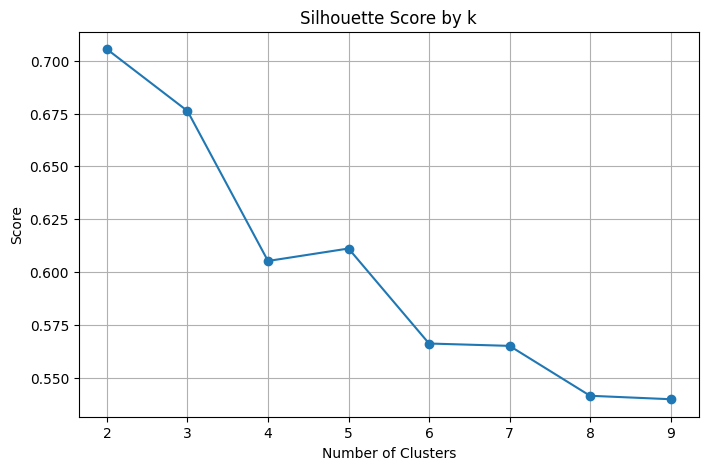

In [26]:
scores = {}
for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_temp = km.fit_predict(embedding)
    scores[k] = silhouette_score(embedding, labels_temp)

best_k = max(scores, key=scores.get)
print("Best k =", best_k)
print("Silhouette scores:", {k: round(v, 3) for k, v in scores.items()})

# Plot
plt.figure(figsize=(8,5))
plt.plot(list(scores.keys()), list(scores.values()), marker='o')
plt.title('Silhouette Score by k')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [27]:
models = {
    "K-Means": KMeans(n_clusters=best_k, n_init=10, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=best_k, linkage="ward")
}

labels = {name: m.fit_predict(embedding) for name, m in models.items()}

def evaluate(lab):
    return {
        "Silhouette": silhouette_score(embedding, lab),
        "Calinski-Harabasz": calinski_harabasz_score(embedding, lab),
        "Davies-Bouldin": davies_bouldin_score(embedding, lab)
    }

results = pd.DataFrame({name: evaluate(lab) for name, lab in labels.items()}).T.round(3)
print(results)

              Silhouette  Calinski-Harabasz  Davies-Bouldin
K-Means            0.705           4475.907           0.467
Hierarchical       0.705           4475.907           0.467


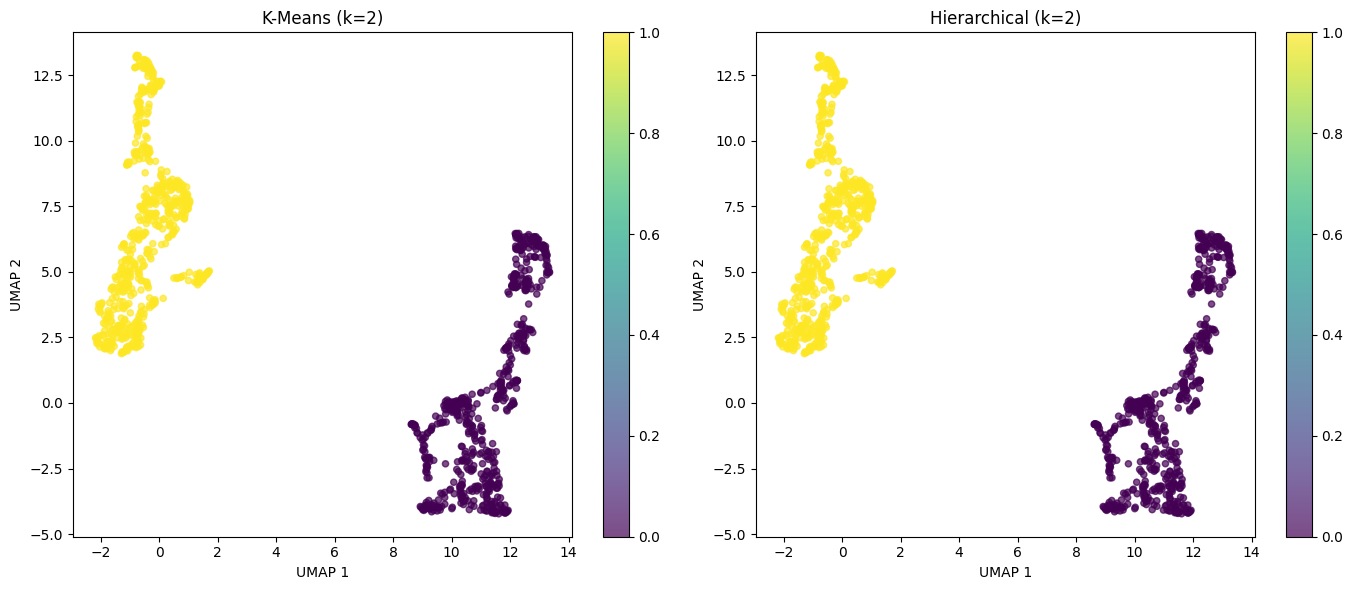

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, lab) in zip(axes, labels.items()):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=lab, cmap='viridis', s=20, alpha=0.7)
    ax.set_title(f"{name} (k={best_k})")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.colorbar(scatter, ax=ax)
plt.tight_layout()
plt.show()

In [29]:
# === Assign Meaningful Cluster Names ===
df['cluster'] = labels['K-Means']

# Map clusters to readable names based on profiles
cluster_names = {
    0: "Renewable_Boost",      # High Clean, Solar, better Germany radiation
    1: "Traditional_Dominant"  # High Traditional Energy, lower renewables
}

df['cluster_name'] = df['cluster'].map(cluster_names)

# === Final Cluster Profiles with Names ===
profile = df.groupby('cluster_name').agg({
    'Clean_Energy_Close': 'mean',
    'Solar_Close': 'mean',
    'Wind_Close': 'mean',
    'Traditional_Energy_Close': 'mean',
    'Texas_USA_Max_Temp_C': 'mean',
    'Germany_Solar_Radiation_MJm2': 'mean',
    'Date': 'count'   # number of days
}).round(2)

profile = profile.rename(columns={'Date': 'Num_Days'})
print("=== FINAL CLUSTER PROFILES WITH NAMES ===\n")
print(profile)

=== FINAL CLUSTER PROFILES WITH NAMES ===

                      Clean_Energy_Close  Solar_Close  Wind_Close  \
cluster_name                                                        
Renewable_Boost                    19.64        76.90       17.90   
Traditional_Dominant               13.85        42.54       16.77   

                      Traditional_Energy_Close  Texas_USA_Max_Temp_C  \
cluster_name                                                           
Renewable_Boost                          31.21                 26.73   
Traditional_Dominant                     43.03                 26.06   

                      Germany_Solar_Radiation_MJm2  Num_Days  
cluster_name                                                  
Renewable_Boost                              12.68       604  
Traditional_Dominant                         11.12       649  


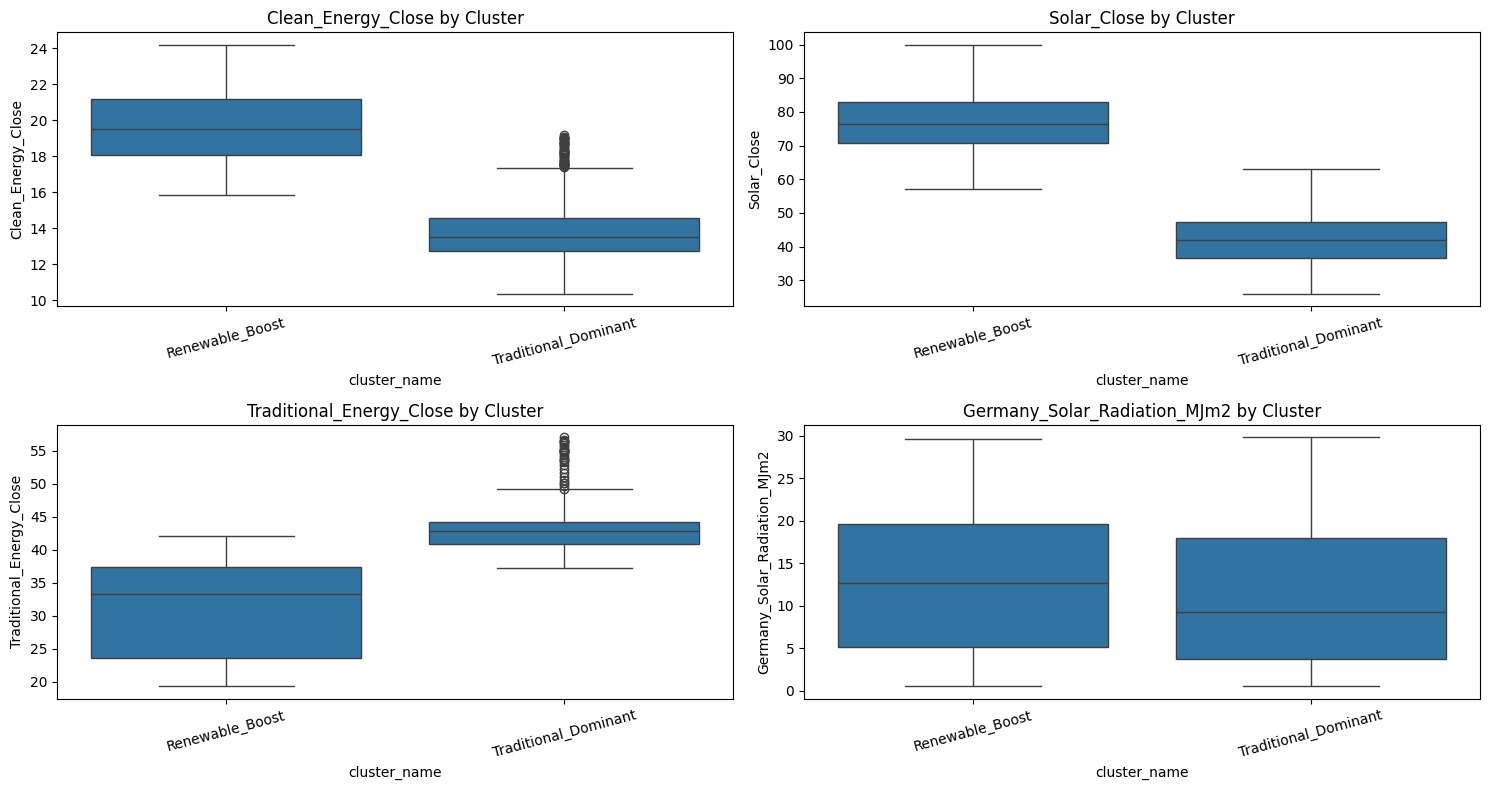

In [30]:
plt.figure(figsize=(15, 8))
metrics = ['Clean_Energy_Close', 'Solar_Close', 'Traditional_Energy_Close',
           'Germany_Solar_Radiation_MJm2']

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='cluster_name', y=metric, data=df)
    plt.title(f'{metric} by Cluster')
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

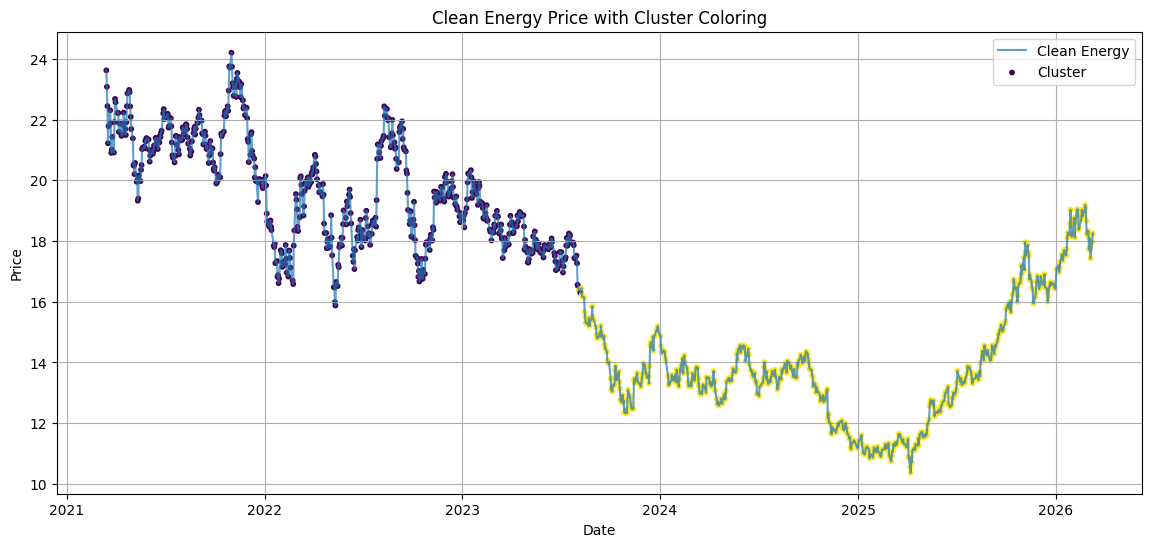

In [31]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Clean_Energy_Close'], label='Clean Energy', alpha=0.7)
plt.scatter(df['Date'], df['Clean_Energy_Close'],
            c=df['cluster'], cmap='viridis', s=10, label='Cluster')
plt.title('Clean Energy Price with Cluster Coloring')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


The clustering analysis successfully identified two distinct regimes in the renewable energy and climate nexus data:





*   Renewable_Boost Regime (604 days): This regime is characterized by significantly stronger performance in clean energy markets. Clean energy stocks close at an average of 19.64, with solar performing particularly well at 76.90. Traditional energy is relatively weaker (31.21). These periods are associated with slightly better solar radiation conditions in Germany (12.68 MJ/m²). This suggests favorable market and weather conditions that support renewable energy outperformance.
*   Traditional_Dominant Regime (649 days): In contrast, this regime shows weak renewable performance, with clean energy closing at only 13.85 and solar at 42.54. Traditional energy stocks dominate strongly (43.03). Solar radiation in Germany is lower (11.12 MJ/m²). This regime reflects periods where fossil fuel-based traditional energy maintains a clear advantage.
                                                                              

*  Overall Insight: The market exhibits a clear bifurcation between
renewable-friendly periods (driven by stronger solar conditions and investor preference for clean energy) and traditional energy-dominant periods. The near-equal split (604 vs 649 days) highlights how sensitive renewable stocks are to climate variables and broader energy market dynamics. These two regimes can be used for regime-switching investment strategies or risk management



                                                                              